# Quad ESC lane

One motor of a quadrotor: a throttle lane under `coaxial.motion.velocity`, the propeller law fed to the model's load.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


The drive commutates itself at 50 kHz from the record's tune; the lane reads `omega_hat` and writes `iq_ref` at link rate. A write lands in about 7 ms, so nothing here runs faster than a few tens of hertz - a quad's rate loop belongs where 50 kHz lives, in `drive/`, and what runs here is what a flight controller would do with this board on the other end of a wire.

`load_k` is the loop's knowledge of the propeller, the law its feedforward leans on; the drag itself is a torque on the machine, so the watch feeds `k w^2` to the model each pass.

In [3]:
drive = device.drive
drive.source('model')
drive.model_param(j=2e-5, b=1e-5, load=0.0)
device.gates.arm(bypass_sto=True, ignore_interlock=True)
poles = int(drive.params()['motor_pole_pairs'])
log = []

In [4]:
import math

TWO_PI = 2.0 * math.pi

def prop_load(k):
    def watch(v):
        wm = drive.model()['omega'] / poles
        drive.model_param(load=k * wm * abs(wm))
        log.append((len(log) * v.pause, v.bus.w_ref * 60.0 / TWO_PI, v.rpm_now,
                    v.bus.iq_ref))
    return watch

In [5]:
K_PROP = 2e-8
with device.motion.velocity(amps=2.0, hz=3.0, load_k=K_PROP) as lane:
    for rpm, hold in ((1500.0, 2.0), (3000.0, 2.0), (2000.0, 1.5), (3500.0, 2.0)):
        got = lane.rpm(rpm, seconds=hold, watch=prop_load(K_PROP))
        print('asked %5.0f  settled %5.0f rpm' % (rpm, got))
    lane.stop(seconds=1.0)
device.gates.disarm()
drive.model_param(load=0.0)
drive.source('adc')

asked  1500  settled  1493 rpm


asked  3000  settled  2932 rpm


asked  2000  settled  2058 rpm


asked  3500  settled  3324 rpm


True

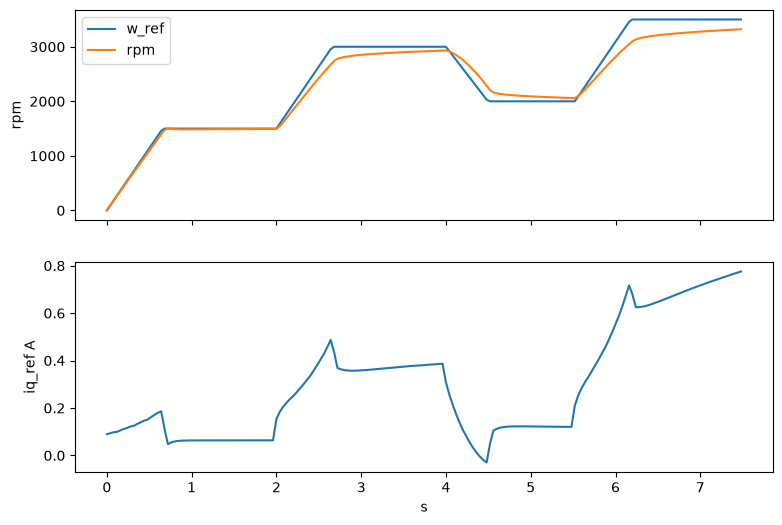

In [6]:
import matplotlib.pyplot as plt

t = [r[0] for r in log]
fig, (a, b) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
a.plot(t, [r[1] for r in log], label='w_ref'); a.plot(t, [r[2] for r in log], label='rpm')
a.set_ylabel('rpm'); a.legend()
b.plot(t, [r[3] for r in log]); b.set_ylabel('iq_ref A'); b.set_xlabel('s')
plt.show()
device.close()

## Conclusions

In [7]:
rate = len(log) / log[-1][0]
print('passes           %d at %.0f Hz, %.0f ms a pass' % (len(log), rate, 1000.0 / rate))
print('iq_ref           %.2f A peak, %.2f A mean'
      % (max(abs(r[3]) for r in log), sum(r[3] for r in log) / len(log)))
for name, target in (('1500', 1500.0), ('3000', 3000.0), ('2000', 2000.0), ('3500', 3500.0)):
    settled = [r[2] for r in log if abs(r[1] - target) < 1.0]
    if settled:
        held = settled[len(settled) // 2:]
        print('at %-5s rpm      held %.0f, spread %.0f rpm over %d passes'
              % (name, sum(held) / len(held), max(held) - min(held), len(held)))

passes           188 at 25 Hz, 40 ms a pass
iq_ref           0.78 A peak, 0.30 A mean
at 1500  rpm      held 1491, spread 4 rpm over 17 passes
at 3000  rpm      held 2904, spread 181 rpm over 18 passes
at 2000  rpm      held 2072, spread 30 rpm over 13 passes
at 3500  rpm      held 3292, spread 61 rpm over 17 passes


The reference slews rather than steps - by default it reaches the target in a third of the block - so the current stays a control action instead of a step into the clamp. The loop's PI cancels the mechanical pole: kp is `w0 J / kt`, and the plant about the reference is `J s + b + 2 k |w_ref|`, because a propeller linearises to twice its slope. The feedforward carries the acceleration and the standing drag, and the integrator holds on the current clamp and on the inner loop's `v_sat` - past either, error is not information.

`j` and `b` default to the smallest plausible machine on purpose: an overstated `j` scales kp by the same factor, and the discrete loop flips sign and doubles - measured, `j` five times the plant took +900 rpm asked to -1552 delivered. Understating only makes a big machine sluggish. `speed_loop.ipynb` identifies the real pair.